In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


# 10 — Class Imbalance Analysis
### Early Sepsis Detection — Phase 12

The training set has a **6.26% positive rate** (27,560 patients, ~1,724
positive) — a real, clinically-expected imbalance (matches Phase 2's
patient-level prevalence of 7.269% on the full dataset, before the Phase 7
exclusions).

**This notebook does NOT apply SMOTE**, per the project's explicit
requirement. Instead we examine class weights and `scale_pos_weight`
(gradient boosting) options, and explain why raw accuracy is not a
sufficient metric for this problem.


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
y_train = npz["y_train"]

print(f"Train positive rate: {y_train.mean():.4f} ({y_train.sum()} / {len(y_train)})")


Train positive rate: 0.0626 (1724 / 27560)


## 1. Why accuracy is NOT a sufficient metric here

**What?** A trivial "always predict negative" classifier on this training
set.

**Why this matters:** it achieves high accuracy while being clinically
useless (0% sensitivity — it would miss every single septic patient).
This is why Phases 13-17 report ROC-AUC, PR-AUC, precision, recall,
specificity, and Brier score — never accuracy alone.


In [3]:
trivial_accuracy = (y_train == 0).mean()
print(f"Accuracy of an 'always predict negative' classifier: {trivial_accuracy:.4f} ({trivial_accuracy*100:.2f}%)")
print(f"Sensitivity (recall) of that same classifier: 0.0000 (it never predicts positive)")
print()
print("This demonstrates why accuracy alone is a misleading metric for this "
      "class-imbalanced clinical prediction task.")


Accuracy of an 'always predict negative' classifier: 0.9374 (93.74%)
Sensitivity (recall) of that same classifier: 0.0000 (it never predicts positive)

This demonstrates why accuracy alone is a misleading metric for this class-imbalanced clinical prediction task.


## 2. Class weight options

**Option A — Balanced class weight (scikit-learn `class_weight='balanced'`):**
Automatically weights each class inversely proportional to its frequency:
`weight_i = n_samples / (n_classes * n_samples_i)`.


In [4]:
n_samples = len(y_train)
n_pos = int(y_train.sum())
n_neg = n_samples - n_pos

weight_pos_balanced = n_samples / (2 * n_pos)
weight_neg_balanced = n_samples / (2 * n_neg)

print(f"'balanced' class_weight would assign:")
print(f"  Negative class weight: {weight_neg_balanced:.4f}")
print(f"  Positive class weight: {weight_pos_balanced:.4f}")
print(f"  Ratio (positive/negative): {weight_pos_balanced/weight_neg_balanced:.2f}x")


'balanced' class_weight would assign:
  Negative class weight: 0.5334
  Positive class weight: 7.9930
  Ratio (positive/negative): 14.99x


**Option B — `scale_pos_weight` (XGBoost/LightGBM convention):**
Typically set to `n_negative / n_positive` — directly upweights the
minority (positive) class's contribution to the loss function.


In [5]:
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (n_negative / n_positive) = {scale_pos_weight:.4f}")
print()
print("This value will be used directly in Phase 14's XGBoost/LightGBM/CatBoost "
      "configurations (and compared against an untuned baseline of 1.0).")


scale_pos_weight (n_negative / n_positive) = 14.9861

This value will be used directly in Phase 14's XGBoost/LightGBM/CatBoost configurations (and compared against an untuned baseline of 1.0).


## 3. Why NOT SMOTE (documented per project requirement)

SMOTE (Synthetic Minority Oversampling) generates synthetic positive
examples by interpolating between real ones in feature space. For this
project we deliberately avoid it because:

1. **Clinical validity risk**: interpolating between two septic patients'
   engineered features (e.g. `Lactate_mean`, `HR_slope`) can produce a
   synthetic patient with a physiologically implausible combination of
   values that never occurs in real ICU patients.
2. **Leakage risk if misapplied**: SMOTE must be fit only on the training
   fold if used at all — a common and serious mistake is applying it
   before the train/val/test split, which leaks synthetic neighbors of
   test patients into training. Avoiding SMOTE entirely removes this risk
   category altogether.
3. **Class weighting is often equally or more effective** for tree-based
   and linear models on tabular clinical data, without inventing patients
   that don't exist. This is exactly why we use class_weight/scale_pos_weight
   (Sections 2 above) as the PRIMARY strategy in Phases 13-16.
4. **Threshold optimization (Phase 18)** is the other primary lever
   used, independent of any resampling — adjusting the decision threshold
   directly addresses the "which errors matter more" question this
   dataset's imbalance raises.


## 4. Visualize the imbalance

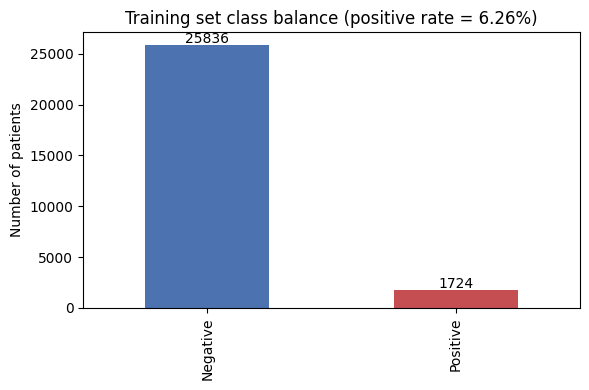

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
pd.Series({"Negative": n_neg, "Positive": n_pos}).plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title(f"Training set class balance (positive rate = {y_train.mean():.2%})")
ax.set_ylabel("Number of patients")
for i, v in enumerate([n_neg, n_pos]):
    ax.text(i, v + 200, str(v), ha="center")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "10_class_imbalance.png", dpi=150)
plt.show()


---
### What to send back to Claude after running this notebook

- Section 1's trivial-classifier accuracy (should be ~93.74%, the mirror
  of the 6.26% positive rate)
- Section 2's balanced-weight and scale_pos_weight values (these will be
  reused directly in Phase 13-16 model configurations)

With that, **Phase 12 is complete**, and we move to **Phase 13 — the first
model: baseline Logistic Regression**, using `class_weight='balanced'`
and the full evaluation metric suite (ROC-AUC, PR-AUC, precision, recall,
specificity, Brier score, ROC/PR/calibration curves).
